In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# It's a good idea to ensure you're running the latest version of any libraries you need.
# `!pip install -Uqq <libraries>` upgrades to the latest version of <libraries>
# NB: You can safely ignore any warnings or errors pip spits out about running as root or incompatibilities
import os
iskaggle = os.environ.get('KAGGLE_KERNEL_RUN_TYPE', '')

if iskaggle:
    !pip install -qq fastai ddgs --use-deprecated=legacy-resolver 

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 43.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 11.3 MB/s eta 0:00:00


In [3]:
from ddgs import DDGS #DuckDuckGo has changed the api so we need to update 
from fastcore.all import *
import time, json

# import time
# from duckduckgo_search import DDGS
# from fastcore.all import *

def search_images(keywords, max_images=100, retries=3):
    for i in range(retries):
        try:
            with DDGS() as ddgs:
                results = ddgs.images(keywords, max_results=max_images)
                if not results:
                    return L()
                return L(results).itemgot('image')
        
        except Exception as e:
            # Kui on viimane katse, siis viska viga välja
            if i == retries - 1:
                print(f"Error searching for {keywords}: {e}")
                return L()
            
            # Oota enne uut katset (eksponentsiaalne backoff)
            time.sleep(2 ** i) 
            
    return L()

In [4]:
urls = search_images('salad', max_images=1)
urls[0]

'https://natashaskitchen.com/wp-content/uploads/2019/02/Greek-Salad.jpg'

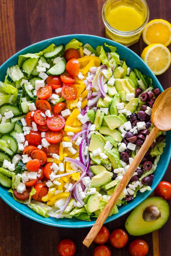

In [5]:
from fastdownload import download_url
salad_image = 'salad.jpg'
download_url(urls[0], salad_image, show_progress=False)

from fastai.vision.all import *
im = Image.open(salad_image)
im.to_thumb(256,256)

In [6]:
food_types = ['vegetarian','non-vegetarian']
path = Path('food')

for o in food_types:
    dest = (path/o)
    dest.mkdir(exist_ok=True, parents=True)
    results = search_images(f'{o} food', max_images=150)
    download_images(dest, urls=results)
    time.sleep(5)

In [7]:
fns = get_image_files(path)
print(len(fns))

failed = verify_images(fns)
print(failed)

failed.map(Path.unlink)

69
[]


[]

In [8]:
food = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=Resize(128))

In [9]:
dls = food.dataloaders(path)

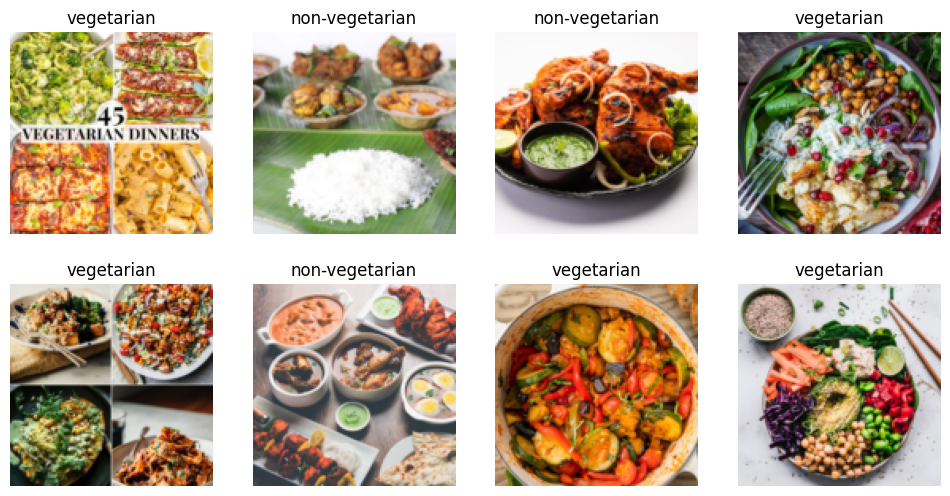

In [10]:
dls.valid.show_batch(max_n=8, nrows=2)

In [11]:
batch_size=16

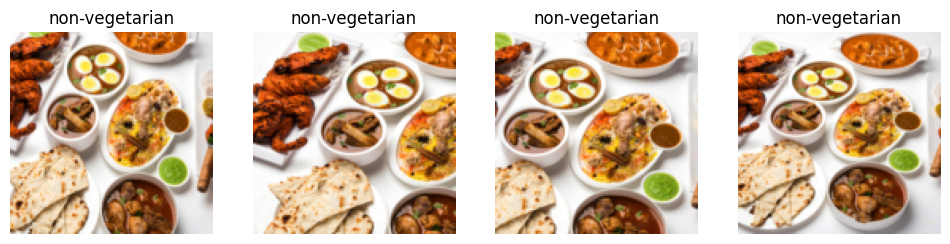

In [12]:
food_random_resized_crop = food.new(item_tfms=RandomResizedCrop(128, min_scale=0.3))
dls_random_resized_crop = food_random_resized_crop.dataloaders(path, bs=batch_size)
#dls_random_resized_crop.valid.show_batch(max_n=8, nrows=2)
dls_random_resized_crop.train.show_batch(max_n=4, nrows=1, unique=True)

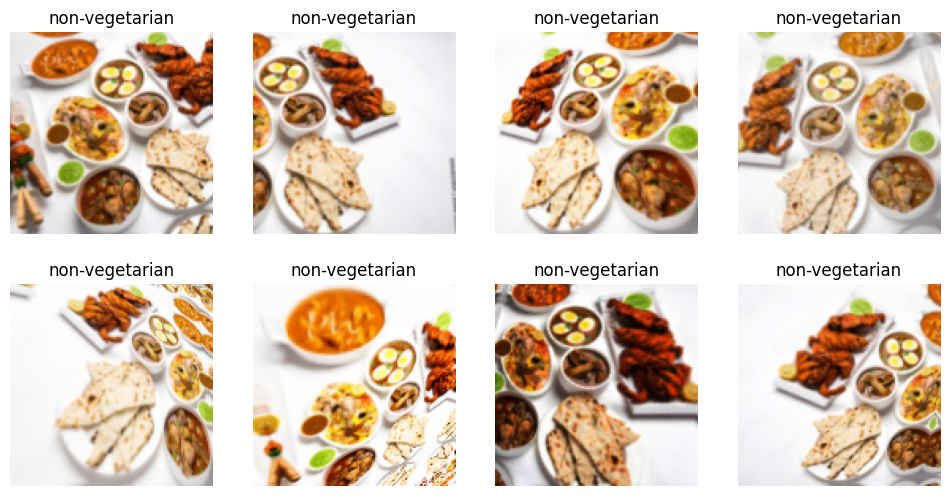

In [13]:
food_batch_tfms = food.new(item_tfms=Resize(128), batch_tfms=aug_transforms(mult=2))
dls_batch_tfms = food_batch_tfms.dataloaders(path, bs=batch_size)
dls_batch_tfms.train.show_batch(max_n=8, nrows=2, unique=True)

In [14]:
food_batch_tfms = food.new(
    item_tfms=RandomResizedCrop(224, min_scale=0.5),
    batch_tfms=aug_transforms())
dls_batch_tfms = food_batch_tfms.dataloaders(path, bs=batch_size)

In [15]:
learn = vision_learner(dls_batch_tfms, resnet18, metrics=error_rate)
learn.fine_tune(4)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 146MB/s] 


epoch,train_loss,valid_loss,error_rate,time
0,1.595080,1.288327,0.461538,00:07


epoch,train_loss,valid_loss,error_rate,time
0,1.053868,0.494809,0.230769,00:09
1,0.687892,0.144586,0.076923,00:09
2,0.505738,0.049319,0.000000,00:09
3,0.432244,0.030766,0.000000,00:09


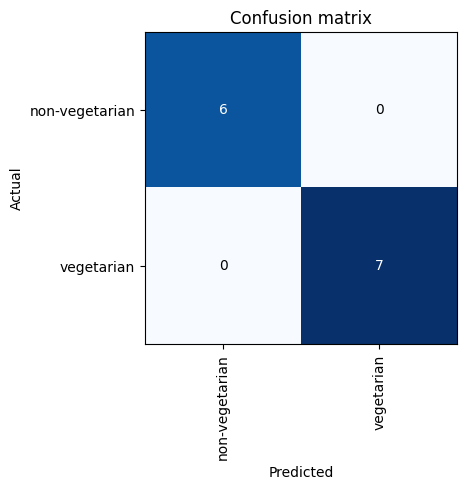

In [16]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

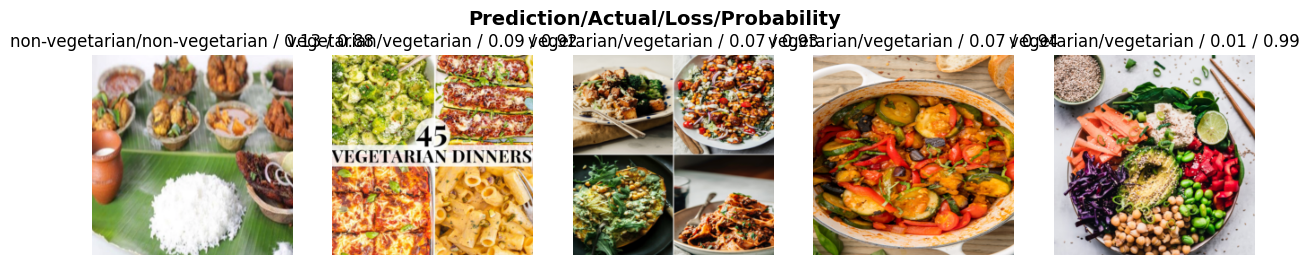

In [17]:
interp.plot_top_losses(5, nrows=1)

In [18]:
from fastai.vision.widgets import *
cleaner = ImageClassifierCleaner(learn)
cleaner

In [19]:
learn.export()

In [20]:
path = Path()
path.ls(file_exts='.pkl')

[Path('export.pkl')]

In [21]:
learn_inf = load_learner(path/'export.pkl')

/usr/local/lib/python3.12/dist-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


In [22]:
learn_inf.predict(salad_image)

('vegetarian', tensor(1), tensor([0.0012, 0.9988]))

In [23]:
learn_inf.dls.vocab

['non-vegetarian', 'vegetarian']

In [24]:
!pip install ipywidgets --upgrade
!pip install jupyterlab_widgets --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 3.4 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: ipywidgets
    Found existing installation: ipywidgets 8.1.5
    Uninstalling ipywidgets-8.1.5:
      Successfully uninstalled ipywidgets-8.1.5


In [25]:
btn_upload = widgets.FileUpload()
btn_upload

FileUpload(value=(), description='Upload')

In [26]:
print(btn_upload)

FileUpload(value=(), description='Upload')


In [27]:
def getUploadedImage(btn_upload):
    if isinstance(btn_upload, SimpleNamespace):
        img = PILImage.create(btn_upload.data[-1])
    else:
        if len(btn_upload.value) > 0:
            img = Image.open(io.BytesIO(btn_upload.value[0].content))
        else:
            img = None
    return img
        
# For the book, we can't actually click an upload button, so we fake it
btn_upload = SimpleNamespace(data = [salad_image])
img = getUploadedImage(btn_upload)

In [28]:
out_pl = widgets.Output()
out_pl.clear_output()
with out_pl: display(img.to_thumb(128,128))
out_pl

Output()

In [29]:
pred,pred_idx,probs = learn_inf.predict(img)
lbl_pred = widgets.Label()
lbl_pred.value = f'Prediction: {pred}; Probability: {probs[pred_idx]:.04f}'
lbl_pred

Label(value='Prediction: vegetarian; Probability: 0.9988')

In [30]:
btn_run = widgets.Button(description='Classify')
btn_run

Button(description='Classify', style=ButtonStyle())

In [31]:
def on_click_classify(change):
    img = getUploadedImage(btn_upload)
    out_pl.clear_output()
    with out_pl: display(img.to_thumb(128,128))
    pred,pred_idx,probs = learn_inf.predict(img)
    lbl_pred.value = f'Prediction: {pred}; Probability: {probs[pred_idx]:.04f}'

btn_run.on_click(on_click_classify)

In [32]:
btn_upload = widgets.FileUpload()
VBox([widgets.Label('Select your food!'), 
      btn_upload, btn_run, out_pl, lbl_pred])

In [33]:
# create example image set
food_examples = ['salad', 'steak', 'grilled fish', 'fruits']
food_example_files = []
for food_example in food_examples:
    url = search_images(food_example, max_images=1)[0]
    output_file_name = food_example.replace(' ', '_') + '.jpg'
    food_example_files.append(output_file_name)
    download_url(url, output_file_name, show_progress=False)
    

In [34]:
#!pip install voila
#!jupyter serverextension enable --sys-prefix voila

In [35]:
!pip install -q gradio pyngrok

In [36]:
from pyngrok import ngrok
ngrok.set_auth_token("3DmL62lJWjjqYikZZQqJuLtrfeY_62jAWpDXiUmaHtnz8968d")

In [37]:
import gradio as gr

def classify_image(img):
    # Predict returns: pred_class, pred_idx, probabilities
    pred, idx, probs = learn_inf.predict(img)
    
    # Define the categories your model predicts
    categories = learn_inf.dls.vocab
    
    # Return probabilities as a dictionary for Gradio
    return dict(zip(categories, map(float, probs)))

# Create the Gradio interface
image = gr.Image()
label = gr.Label()
examples = food_example_files # Optional: Add paths to sample images

demo = gr.Interface(
    fn=classify_image, 
    inputs=image, 
    outputs=label, 
    examples=examples,
    title="Food Classifier",
    description="An image classifier built with fast.ai and Gradio."
)

# Launch on port 7860 without sharing
gradio_port=7860
demo.launch(server_port=gradio_port, share=False)

# Expose the port to the public using ngrok
public_url = ngrok.connect(gradio_port)
print(f"Public URL: {public_url.public_url}")

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


Public URL: https://transform-evolve-sector.ngrok-free.dev
